In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import marimo as mo
import scipy.stats as st

from pathlib import Path

sys.path.insert(0, os.path.abspath("C:\\Users\\rhanes\\GitHub\\tyche\\src"))

import tyche as ty

In [217]:
saveresults = True

In [3]:
createplots = False

In [4]:
start_year_atb = 2010
end_year_atb = 2060
start_year_timeseries = 2022

In [5]:
designs = ty.Designs(
    path = '.',
    name = 'nuclear.xlsx' # nuclear-fixed.xlsx contains point estimate scenarios
)
investments = ty.Investments(
    path = '.',
    name = 'nuclear.xlsx'
)

designs.compile()

In [5]:
tranche_results = investments.evaluate_tranches(designs, sample_count=5000).metrics
#tranche_results.xs(1, level="Sample", drop_level=False)

In [ ]:
if createplots:
    g = sb.boxenplot(
        x="Tranche",
        y="Value",
        hue="Technology",
        data=tranche_results.xs(
            "Construction Duration",
            level="Index"
        ).reset_index(
        )[["Technology", "Category", "Tranche", "Value"]],
        order=[
            "FOAK 6 Orders",
            "BOAK 2 of 6 Orders",
            "BOAK 3 of 6 Orders",
            "BOAK 4 of 6 Orders",
            "BOAK 5 of 6 Orders",
            "NOAK 6 Orders",
            ]
        )
    g.set(ylabel="Construction Duration (months)",
         ylim=(0,300))
    g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    #g.legend()

In [ ]:
if createplots:
    g = sb.boxenplot(
        x="Tranche",
        y="Value",
        hue="Technology",
        data=tranche_results.xs(
            "Levelized Net OCC",
            level="Index"
        ).reset_index(
        )[["Technology", "Category", "Tranche", "Value"]],
        order=[
            "FOAK 6 Orders",
            "BOAK 2 of 6 Orders",
            "BOAK 3 of 6 Orders",
            "BOAK 4 of 6 Orders",
            "BOAK 5 of 6 Orders",
            "NOAK 6 Orders",
            ]
        )
    g.set(ylabel="Levelized Net OCC",
         ylim=(0,32000))
    g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    #g.legend()

In [ ]:
if createplots:
    g = sb.boxenplot(
        x="Tranche",
        y="Value",
        hue="Technology",
        data=tranche_results.xs(
            "Construction Duration",
            level="Index"
        ).reset_index(
        )[["Technology", "Category", "Tranche", "Value"]],
        order=[
            "FOAK 3 Orders",
            "BOAK 3 Orders",
            "NOAK 3 Orders",
            "FOAK 6 Orders",
            "BOAK 6 Orders",
            "NOAK 6 Orders",
            "FOAK 13 Orders",
            "BOAK 13 Orders",
            "NOAK 13 Orders"
            ]
        )
    g.set(ylabel="Construction Duration (months)",
         ylim=(0,300))
    g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    #g.legend()

In [ ]:
if createplots:
    g = sb.boxenplot(
        x="Tranche",
        y="Value",
        hue="Technology",
        data=tranche_results.xs(
            "Levelized Net OCC",
            level="Index"
        ).reset_index(
        )[["Technology", "Category", "Tranche", "Value"]],
        order=[
            "FOAK 3 Orders",
            "BOAK 3 Orders",
            "NOAK 3 Orders",
            "FOAK 6 Orders",
            "BOAK 6 Orders",
            "NOAK 6 Orders",
            "FOAK 13 Orders",
            "BOAK 13 Orders",
            "NOAK 13 Orders"
            ]
        )
    g.set(ylabel="Levelized Net OCC",
         ylim=(0,32000))
    g.set_xticklabels(g.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    #g.legend()

In [17]:
tranches_timeseries = tranche_results.reset_index()

tranches_timeseries.drop(
    columns = ['Category','Units'],
    inplace = True
)

tranches_timeseries.rename(
    columns = {'Sample': 'sampl'},
    inplace = True
)

tranches_timeseries = tranches_timeseries[tranches_timeseries.Tranche.isin([
        "FOAK 6 Orders",
        "BOAK 2 of 6 Orders",
        "BOAK 3 of 6 Orders",
        "BOAK 4 of 6 Orders",
        "BOAK 5 of 6 Orders",
        "NOAK 6 Orders"
])]

tranches_timeseries = tranches_timeseries[tranches_timeseries.Index.isin([
    "Construction Duration",
    "Fixed Op and Maint",
    "Variable Op and Maint",
    "Levelized Net OCC"
])]

tranches_timeseries['plant'] = 1
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 2 of 6 Orders','plant'] = 2
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 3 of 6 Orders','plant'] = 3
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 4 of 6 Orders','plant'] = 4
tranches_timeseries.loc[tranches_timeseries.Tranche == 'BOAK 5 of 6 Orders','plant'] = 5
tranches_timeseries.loc[tranches_timeseries.Tranche == 'NOAK 6 Orders','plant'] = 6

tranches_timeseries_occ = tranches_timeseries.loc[tranches_timeseries.Index == 'Levelized Net OCC', ['Technology','sampl','Value','plant']]
tranches_timeseries_duration = tranches_timeseries.loc[tranches_timeseries.Index == 'Construction Duration', ['Technology','sampl','Value','plant']]
tranches_timeseries_fom = tranches_timeseries.loc[tranches_timeseries.Index == 'Fixed Op and Maint', ['Technology','sampl','Value','plant']]
tranches_timeseries_vom = tranches_timeseries.loc[tranches_timeseries.Index == 'Variable Op and Maint', ['Technology','sampl','Value','plant']]

tranches_atb = tranches_timeseries_occ.merge(tranches_timeseries_duration,
                                             on = ['Technology','sampl','plant'],
                                             suffixes=('_occ', '_cons')
                                            ).merge(tranches_timeseries_fom,
                                                    on = ['Technology','sampl','plant']
                                                   ).merge(tranches_timeseries_vom,
                                                           on = ['Technology','sampl','plant'],
                                                           suffixes = ('_fom','_vom'))

tranches_atb.rename(
    columns = {'Value_occ': 'capcost',
              'Value_cons': 'cons_months',
              'Value_fom': 'fom',
              'Value_vom': 'vom'},
    inplace = True
)

tranches_atb['cons_years'] = np.ceil(tranches_atb.cons_months / 12)

tranches_atb['start_year'] = 0
tranches_atb['end_year'] = 0

tranches_atb.loc[tranches_atb.plant == 1, 'start_year'] = start_year_atb
tranches_atb.loc[tranches_atb.plant == 1, 'cons_years'] = (start_year_timeseries - start_year_atb) + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']
tranches_atb.loc[tranches_atb.plant == 1, 'end_year'] = start_year_atb + tranches_atb.loc[tranches_atb.plant == 1, 'cons_years']

for _s in tranches_atb.sampl.sort_values().unique():
    for _p in tranches_atb.plant.sort_values().unique():

        tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'start_year'].values[0] + \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'cons_years'].values[0] - 1
        
        if _p < tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p + 1), 'start_year'] = \
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'].values[0] + 1

        if _p == tranches_atb.plant.max():
            tranches_atb.loc[(tranches_atb.sampl == _s) & (tranches_atb.plant == _p), 'end_year'] = end_year_atb + 1


# Sort first by technology, then sampl, then by plant number within sampl
tranches_atb = tranches_atb.sort_values(by = ['Technology','sampl','plant'])

tranches_atb['years'] = [np.arange(styr, enyr) for styr, enyr in zip(tranches_atb.start_year, tranches_atb.end_year)]

tranches_atb_timeseries = tranches_atb.explode(column = 'years')

if saveresults:
    tranches_atb_timeseries.to_csv('tranches-atb-withyears.csv',index=False)

In [6]:
tranches_atb_timeseries = pd.read_csv('tranches-atb-withyears.csv')

In [9]:
smr_atb_mod = pd.read_csv('nuclear-smr_ATB_2025_moderate.csv')
smr_atb_adv = pd.read_csv('nuclear-smr_ATB_2025_advanced.csv')
smr_atb_con = pd.read_csv('nuclear-smr_ATB_2025_conservative.csv')

In [10]:
lg_atb_mod = pd.read_csv('nuclear_ATB_2025_moderate.csv')
lg_atb_adv = pd.read_csv('nuclear_ATB_2025_advanced.csv')
lg_atb_con = pd.read_csv('nuclear_ATB_2025_conservative.csv')

In [ ]:
if createplots:
    sb.lineplot(
        data = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Nuclear SMR') &
        (tranches_atb_timeseries.years <= end_year_atb)].reset_index(),
        x = 'years',
        y = 'capcost',
        hue = 'sampl',
        alpha = 0.15
    )
    
    sb.lineplot(data = smr_atb_mod,
                x = 't',
                y = 'capcost',
                label = 'Nuclear SMR ATB, Moderate'
               )
    
    sb.lineplot(data = smr_atb_con,
                x = 't',
                y = 'capcost',
                label = 'Nuclear SMR ATB, Conservative'
               )
    
    sb.lineplot(data = smr_atb_adv,
                x = 't',
                y = 'capcost',
                label = 'Nuclear SMR ATB, Advanced'
               )

In [172]:
smr_ci_rawdata = tranches_atb_timeseries.loc[
    (tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)
    ].reset_index()[['years','capcost']]

smr_ci_lower_dict = {}
smr_ci_upper_dict = {}
smr_pi_lower_dict = {}
smr_pi_upper_dict = {}

smr_1_pct_dict = {}
smr_2_5_pct_dict = {}
smr_4_pct_dict = {}

smr_mean_dict = {}
smr_min_dict = {}

for i in sorted(smr_ci_rawdata.years.unique()):
    _ci = st.bootstrap((smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values,),
                       np.mean,
                       axis=0,
                       confidence_level=0.90).confidence_interval
    smr_ci_lower_dict[i] = _ci[0]
    smr_ci_upper_dict[i] = _ci[1]

    smr_pi_lower_dict[i] = np.percentile(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values, 5)
    smr_pi_upper_dict[i] = np.percentile(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values, 95)

    smr_mean_dict[i] = np.mean(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values)
    smr_min_dict[i] = np.min(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values)

    smr_1_pct_dict[i] = np.percentile(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values, 1)
    smr_2_5_pct_dict[i] = np.percentile(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values, 2.5)
    smr_4_pct_dict[i] = np.percentile(smr_ci_rawdata.copy().loc[smr_ci_rawdata.years == i,'capcost'].values, 4)

In [37]:
smr_ci_lower_df = pd.DataFrame.from_dict(smr_ci_lower_dict, orient='index').reset_index()
smr_ci_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_ci_lower_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-ci-lower.csv',index=False)

smr_pi_lower_df = pd.DataFrame.from_dict(smr_pi_lower_dict, orient='index').reset_index()
smr_pi_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_pi_lower_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-pi-lower.csv',index=False)

smr_ci_upper_df = pd.DataFrame.from_dict(smr_ci_upper_dict, orient='index').reset_index()
smr_ci_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_ci_upper_df.merge(smr_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-ci-upper.csv',index=False)

smr_pi_upper_df = pd.DataFrame.from_dict(smr_pi_upper_dict, orient='index').reset_index()
smr_pi_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    smr_pi_upper_df.merge(smr_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-smr-tyche-pi-upper.csv',index=False)

smr_mean_df = pd.DataFrame.from_dict(smr_mean_dict, orient='index').reset_index()
smr_mean_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    smr_mean_df.merge(smr_atb_mod.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-smr-tyche-mean.csv',index=False)

smr_min_df = pd.DataFrame.from_dict(smr_min_dict, orient='index').reset_index()
smr_min_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    smr_min_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-smr-tyche-min.csv',index=False)

smr_2_5_pct_df = pd.DataFrame.from_dict(smr_2_5_pct_dict, orient='index').reset_index()
smr_2_5_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    smr_2_5_pct_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-smr-tyche2_5thpctile.csv',index=False)

smr_1_pct_df = pd.DataFrame.from_dict(smr_1_pct_dict, orient='index').reset_index()
smr_1_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    smr_1_pct_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-smr-tyche-1stpctile.csv',index=False)

smr_4_pct_df = pd.DataFrame.from_dict(smr_4_pct_dict, orient='index').reset_index()
smr_4_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    smr_4_pct_df.merge(smr_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-smr-tyche-4thpctile.csv',index=False)

In [ ]:
sb.lineplot(
    data = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)].reset_index(),
    x = 'years',
    y = 'capcost',
    hue = 'sampl',
    alpha = 0.1,
)

<AxesSubplot: xlabel='t', ylabel='capcost'>

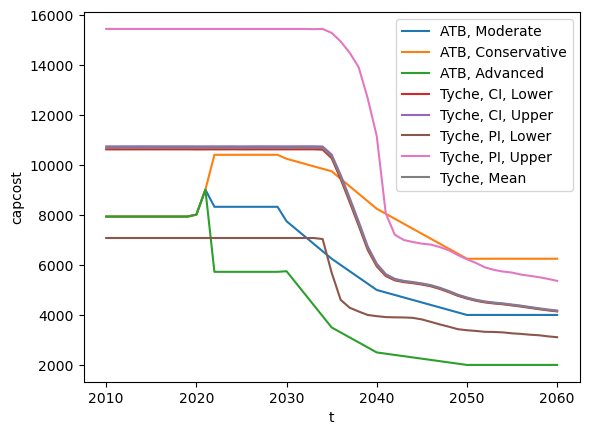

In [30]:
sb.lineplot(data = smr_atb_mod,
            x = 't',
            y = 'capcost',
            label = 'ATB, Moderate'
           )

sb.lineplot(data = smr_atb_con,
            x = 't',
            y = 'capcost',
            label = 'ATB, Conservative'
           )

sb.lineplot(data = smr_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'ATB, Advanced'
           )

sb.lineplot(data = smr_ci_lower_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, CI, Lower'
           )

sb.lineplot(data = smr_ci_upper_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, CI, Upper'
           )

sb.lineplot(data = smr_pi_lower_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, PI, Lower'
           )

sb.lineplot(data = smr_pi_upper_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, PI, Upper'
           )

sb.lineplot(data = smr_mean_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, Mean'
           )

Identify individual samples (timeseries) that are closest to the minimum cost, the lower PI bound, and a couple other values in between those

In [183]:
smr_samples = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)].reset_index()

smr_pi_upper = pd.read_csv('nuclear-smr-tyche-pi-upper.csv')
smr_pi_lower = pd.read_csv('nuclear-smr-tyche-pi-lower.csv')

smr_min_df.rename(
    columns = {'capcost':'capcost_minimum'},
    inplace = True
)

smr_pi_lower.rename(
    columns = {'capcost':'capcost_5thpct'},
    inplace = True
)

smr_1_pct_df.rename(
    columns = {'capcost':'capcost_1stpct'},
    inplace = True
)

smr_2_5_pct_df.rename(
    columns = {'capcost':'capcost_2_5thpct'},
    inplace = True
)

smr_4_pct_df.rename(
    columns = {'capcost':'capcost_4thpct'},
    inplace = True
)

smr_samples = smr_samples.copy().merge(smr_min_df,
                  left_on = 'years',
                  right_on = 't',
                  how = 'outer')

smr_samples = smr_samples.copy().merge(smr_pi_lower,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(smr_1_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(smr_2_5_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(smr_4_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer')

smr_samples['se_minimum'] = (smr_samples.capcost - smr_samples.capcost_minimum) ** 2
smr_samples['se_1stpct'] = (smr_samples.capcost - smr_samples.capcost_1stpct) ** 2
smr_samples['se_2_5thpct'] = (smr_samples.capcost - smr_samples.capcost_2_5thpct) ** 2
smr_samples['se_4thpct'] = (smr_samples.capcost - smr_samples.capcost_4thpct) ** 2
smr_samples['se_5thpct'] = (smr_samples.capcost - smr_samples.capcost_5thpct) ** 2

smr_samples = smr_samples.copy()[['years','sampl','capcost','capcost_minimum','se_minimum','capcost_5thpct','se_1stpct','se_2_5thpct','se_4thpct','se_5thpct']]

C:\Users\rhanes\AppData\Local\Temp\1\ipykernel_12736\4085766423.py:37: FutureWarning: Passing 'suffixes' which cause duplicate columns {'t_x'} in the result is deprecated and will raise a MergeError in a future version.
  smr_samples = smr_samples.copy().merge(smr_pi_lower,


In [184]:
# Group by sample, take the sum over all years of the squared errors
smr_sse = smr_samples[['sampl','se_minimum','se_1stpct','se_2_5thpct','se_4thpct','se_5thpct']].groupby('sampl').agg('sum').reset_index()

smr_sse.rename(
    columns = {'se_minimum':'sse_minimum',
               'se_1stpct': 'sse_1stpct',
               'se_2_5thpct': 'sse_2_5thpct',
               'se_4thpct': 'sse_4thpct',
               'se_5thpct':'sse_5thpct'},
    inplace = True)

smr_sse            

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
0,1,1.657205e+09,1.015497e+09,8.708123e+08,7.667374e+08,7.222407e+08
1,2,1.109373e+09,6.155533e+08,5.032473e+08,4.281320e+08,3.958345e+08
2,3,8.587328e+08,4.125697e+08,3.209386e+08,2.576568e+08,2.314911e+08
3,4,1.127694e+09,6.017749e+08,4.893617e+08,4.094109e+08,3.759270e+08
4,5,2.917736e+09,2.025630e+09,1.815877e+09,1.660055e+09,1.592898e+09
...,...,...,...,...,...,...
4995,4996,1.076887e+09,5.700302e+08,4.642861e+08,3.889993e+08,3.577332e+08
4996,4997,1.450274e+09,8.643182e+08,7.313368e+08,6.380474e+08,5.983551e+08
4997,4998,8.290184e+08,3.910565e+08,3.041462e+08,2.437912e+08,2.199215e+08
4998,4999,6.164601e+08,2.947944e+08,2.289866e+08,1.895259e+08,1.734837e+08


In [185]:
smr_sse.loc[smr_sse.sse_minimum == np.min(smr_sse.sse_minimum)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
1304,1305,5.618625e+07,3.211499e+07,4.946827e+07,7.317671e+07,8.535793e+07


In [186]:
smr_sse.loc[smr_sse.sse_5thpct == np.min(smr_sse.sse_5thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
4310,4311,2.006273e+08,2.815703e+07,1.007144e+07,4.020157e+06,3.543207e+06


In [188]:
smr_sse.loc[smr_sse.sse_1stpct == np.min(smr_sse.sse_1stpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
4638,4639,6.437154e+07,1.686746e+07,2.944375e+07,4.872683e+07,5.939693e+07


In [189]:
smr_sse.loc[smr_sse.sse_2_5thpct == np.min(smr_sse.sse_2_5thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
3485,3486,1.662822e+08,2.116598e+07,8.074026e+06,7.048391e+06,8.396042e+06


In [190]:
smr_sse.loc[smr_sse.sse_4thpct == np.min(smr_sse.sse_4thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
4310,4311,2.006273e+08,2.815703e+07,1.007144e+07,4.020157e+06,3.543207e+06


<AxesSubplot: xlabel='t', ylabel='capcost_minimum'>

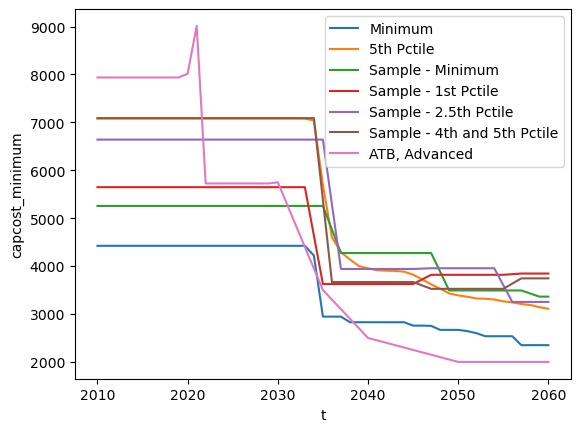

In [193]:
sb.lineplot(data = smr_min_df,
            x = 't',
            y = 'capcost_minimum',
            label = 'Minimum'
           )

sb.lineplot(data = smr_pi_lower,
            x = 't',
            y = 'capcost_5thpct',
            label = '5th Pctile'
           )

sb.lineplot(data = smr_samples.loc[smr_samples.sampl == 1305],
            x = 'years',
            y = 'capcost',
            label = 'Sample - Minimum'
           )

sb.lineplot(data = smr_samples.loc[smr_samples.sampl == 4639],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 1st Pctile'
           )

sb.lineplot(data = smr_samples.loc[smr_samples.sampl == 3486],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 2.5th Pctile'
           )

sb.lineplot(data = smr_samples.loc[smr_samples.sampl == 4311],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 4th and 5th Pctile'
           )

sb.lineplot(data = smr_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'ATB, Advanced'
           )

<AxesSubplot: xlabel='t', ylabel='capcost_minimum'>

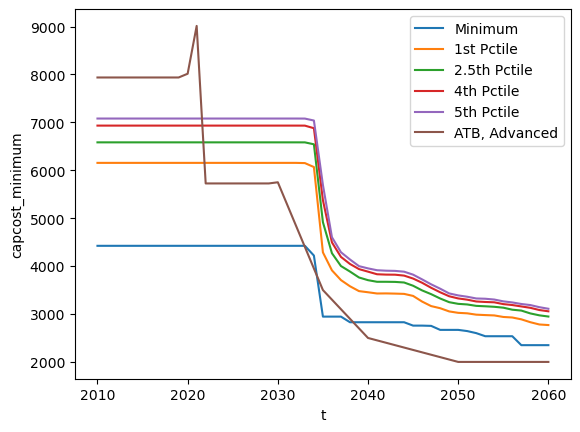

In [195]:
sb.lineplot(data = smr_min_df,
            x = 't',
            y = 'capcost_minimum',
            label = 'Minimum'
           )

sb.lineplot(data = smr_1_pct_df,
            x = 't',
            y = 'capcost_1stpct',
            label = '1st Pctile'
           )

sb.lineplot(data = smr_2_5_pct_df,
            x = 't',
            y = 'capcost_2_5thpct',
            label = '2.5th Pctile'
           )

sb.lineplot(data = smr_4_pct_df,
            x = 't',
            y = 'capcost_4thpct',
            label = '4th Pctile'
           )

sb.lineplot(data = smr_pi_lower,
            x = 't',
            y = 'capcost_5thpct',
            label = '5th Pctile'
           )

sb.lineplot(data = smr_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'ATB, Advanced'
           )

# Large Nuclear

In [219]:
lgnuc_ci_rawdata = tranches_atb_timeseries.loc[
    (tranches_atb_timeseries.Technology == 'Large Nuclear') &
    (tranches_atb_timeseries.years <= end_year_atb)
    ].reset_index()[['years','capcost']]

lgnuc_ci_lower_dict = {}
lgnuc_ci_upper_dict = {}
lgnuc_pi_lower_dict = {}
lgnuc_pi_upper_dict = {}

lgnuc_1_pct_dict = {}
lgnuc_2_5_pct_dict = {}
lgnuc_4_pct_dict = {}

lgnuc_mean_dict = {}
lgnuc_min_dict = {}

for i in sorted(lgnuc_ci_rawdata.years.unique()):
    _ci = st.bootstrap((lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values,),
                       np.mean,
                       axis=0,
                       confidence_level=0.90).confidence_interval
    lgnuc_ci_lower_dict[i] = _ci[0]
    lgnuc_ci_upper_dict[i] = _ci[1]

    lgnuc_pi_lower_dict[i] = np.percentile(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values, 5)
    lgnuc_pi_upper_dict[i] = np.percentile(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values, 95)

    lgnuc_mean_dict[i] = np.mean(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values)
    lgnuc_min_dict[i] = np.min(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values)

    lgnuc_1_pct_dict[i] = np.percentile(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values, 1)
    lgnuc_2_5_pct_dict[i] = np.percentile(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values, 2.5)
    lgnuc_4_pct_dict[i] = np.percentile(lgnuc_ci_rawdata.copy().loc[lgnuc_ci_rawdata.years == i,'capcost'].values, 4)


lgnuc_ci_lower_df = pd.DataFrame.from_dict(lgnuc_ci_lower_dict, orient='index').reset_index()
lgnuc_ci_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_ci_lower_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-ci-lower.csv',index=False)

lgnuc_pi_lower_df = pd.DataFrame.from_dict(lgnuc_pi_lower_dict, orient='index').reset_index()
lgnuc_pi_lower_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_pi_lower_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-pi-lower.csv',index=False)

lgnuc_ci_upper_df = pd.DataFrame.from_dict(lgnuc_ci_upper_dict, orient='index').reset_index()
lgnuc_ci_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_ci_upper_df.merge(lg_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-ci-upper.csv',index=False)

lgnuc_pi_upper_df = pd.DataFrame.from_dict(lgnuc_pi_upper_dict, orient='index').reset_index()
lgnuc_pi_upper_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace=True
)

if saveresults:
    lgnuc_pi_upper_df.merge(lg_atb_con.loc[:,['i','t','fom','vom','heatrate']],
                          on='t',
                          how='outer'
                         ).to_csv('nuclear-large-tyche-pi-upper.csv',index=False)

lgnuc_mean_df = pd.DataFrame.from_dict(lgnuc_mean_dict, orient='index').reset_index()
lgnuc_mean_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    lgnuc_mean_df.merge(lg_atb_mod.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-large-tyche-mean.csv',index=False)

lgnuc_min_df = pd.DataFrame.from_dict(lgnuc_min_dict, orient='index').reset_index()
lgnuc_min_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    lgnuc_min_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-large-tyche-min.csv',index=False)

lgnuc_2_5_pct_df = pd.DataFrame.from_dict(lgnuc_2_5_pct_dict, orient='index').reset_index()
lgnuc_2_5_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    lgnuc_2_5_pct_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-large-tyche2_5thpctile.csv',index=False)

lgnuc_1_pct_df = pd.DataFrame.from_dict(lgnuc_1_pct_dict, orient='index').reset_index()
lgnuc_1_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    lgnuc_1_pct_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-large-tyche-1stpctile.csv',index=False)

lgnuc_4_pct_df = pd.DataFrame.from_dict(lgnuc_4_pct_dict, orient='index').reset_index()
lgnuc_4_pct_df.rename(
    columns = {'index':'t',
               0: 'capcost'},
    inplace = True
)

if saveresults:
    lgnuc_4_pct_df.merge(lg_atb_adv.loc[:,['i','t','fom','vom','heatrate']],
                      on='t',
                      how = 'outer'
                     ).to_csv('nuclear-large-tyche-4thpctile.csv',index=False)

In [206]:
lgnuc_samples = tranches_atb_timeseries.loc[(tranches_atb_timeseries.Technology == 'Large Nuclear') &
    (tranches_atb_timeseries.years <= end_year_atb)].reset_index()

lgnuc_pi_upper = pd.read_csv('nuclear-large-tyche-pi-upper.csv')
lgnuc_pi_lower = pd.read_csv('nuclear-large-tyche-pi-lower.csv')

lgnuc_min_df.rename(
    columns = {'capcost':'capcost_minimum'},
    inplace = True
)

lgnuc_pi_lower.rename(
    columns = {'capcost':'capcost_5thpct'},
    inplace = True
)

lgnuc_1_pct_df.rename(
    columns = {'capcost':'capcost_1stpct'},
    inplace = True
)

lgnuc_2_5_pct_df.rename(
    columns = {'capcost':'capcost_2_5thpct'},
    inplace = True
)

lgnuc_4_pct_df.rename(
    columns = {'capcost':'capcost_4thpct'},
    inplace = True
)

lgnuc_samples = lgnuc_samples.copy().merge(lgnuc_min_df,
                  left_on = 'years',
                  right_on = 't',
                  how = 'outer')

lgnuc_samples = lgnuc_samples.copy().merge(lgnuc_pi_lower,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(lgnuc_1_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(lgnuc_2_5_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer').merge(lgnuc_4_pct_df,
                                       left_on = 'years',
                                       right_on = 't',
                                       how = 'outer')

lgnuc_samples['se_minimum'] = (lgnuc_samples.capcost - lgnuc_samples.capcost_minimum) ** 2
lgnuc_samples['se_1stpct'] = (lgnuc_samples.capcost - lgnuc_samples.capcost_1stpct) ** 2
lgnuc_samples['se_2_5thpct'] = (lgnuc_samples.capcost - lgnuc_samples.capcost_2_5thpct) ** 2
lgnuc_samples['se_4thpct'] = (lgnuc_samples.capcost - lgnuc_samples.capcost_4thpct) ** 2
lgnuc_samples['se_5thpct'] = (lgnuc_samples.capcost - lgnuc_samples.capcost_5thpct) ** 2

lgnuc_samples = lgnuc_samples.copy()[['years','sampl','capcost','capcost_minimum','se_minimum','capcost_5thpct','se_1stpct','se_2_5thpct','se_4thpct','se_5thpct']]

C:\Users\rhanes\AppData\Local\Temp\1\ipykernel_12736\2294836160.py:37: FutureWarning: Passing 'suffixes' which cause duplicate columns {'t_x'} in the result is deprecated and will raise a MergeError in a future version.
  lgnuc_samples = lgnuc_samples.copy().merge(lgnuc_pi_lower,


In [207]:
# Group by sample, take the sum over all years of the squared errors
lgnuc_sse = lgnuc_samples[['sampl','se_minimum','se_1stpct','se_2_5thpct','se_4thpct','se_5thpct']].groupby('sampl').agg('sum').reset_index()

lgnuc_sse.rename(
    columns = {'se_minimum':'sse_minimum',
               'se_1stpct': 'sse_1stpct',
               'se_2_5thpct': 'sse_2_5thpct',
               'se_4thpct': 'sse_4thpct',
               'se_5thpct':'sse_5thpct'},
    inplace = True)

lgnuc_sse 

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
0,1,4.266778e+09,3.190267e+09,2.777876e+09,2.565983e+09,2.426280e+09
1,2,3.525281e+09,2.586252e+09,2.228888e+09,2.047166e+09,1.928168e+09
2,3,4.034627e+08,1.404472e+08,7.758132e+07,5.476260e+07,4.406576e+07
3,4,2.384053e+09,1.590574e+09,1.300733e+09,1.158130e+09,1.063696e+09
4,5,8.551009e+08,4.261303e+08,2.917789e+08,2.307548e+08,1.943777e+08
...,...,...,...,...,...,...
4995,4996,5.148546e+08,2.009405e+08,1.153399e+08,8.085897e+07,6.246145e+07
4996,4997,3.251151e+09,2.353093e+09,2.014220e+09,1.841939e+09,1.730275e+09
4997,4998,4.229312e+08,1.684293e+08,1.086648e+08,8.789048e+07,8.009393e+07
4998,4999,1.079500e+09,5.840150e+08,4.234084e+08,3.497990e+08,3.063677e+08


In [208]:
lgnuc_sse.loc[lgnuc_sse.sse_minimum == np.min(lgnuc_sse.sse_minimum)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
3683,3684,4.498082e+07,7.464435e+07,1.356951e+08,1.797791e+08,2.156255e+08


In [210]:
lgnuc_sse.loc[lgnuc_sse.sse_5thpct == np.min(lgnuc_sse.sse_5thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
2889,2890,2.759294e+08,5.865462e+07,1.605372e+07,5.883539e+06,3.535158e+06


In [211]:
lgnuc_sse.loc[lgnuc_sse.sse_1stpct == np.min(lgnuc_sse.sse_1stpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
1572,1573,1.291667e+08,1.782159e+07,1.730169e+07,2.903391e+07,4.274997e+07


In [212]:
lgnuc_sse.loc[lgnuc_sse.sse_2_5thpct == np.min(lgnuc_sse.sse_2_5thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
4791,4792,1.934404e+08,2.574604e+07,4.590166e+06,5.346724e+06,1.063433e+07


In [213]:
lgnuc_sse.loc[lgnuc_sse.sse_4thpct == np.min(lgnuc_sse.sse_4thpct)]

,sampl,sse_minimum,sse_1stpct,sse_2_5thpct,sse_4thpct,sse_5thpct
4168,4169,2.307985e+08,4.053628e+07,9.274425e+06,4.805584e+06,6.565975e+06


<AxesSubplot: xlabel='t', ylabel='capcost_minimum'>

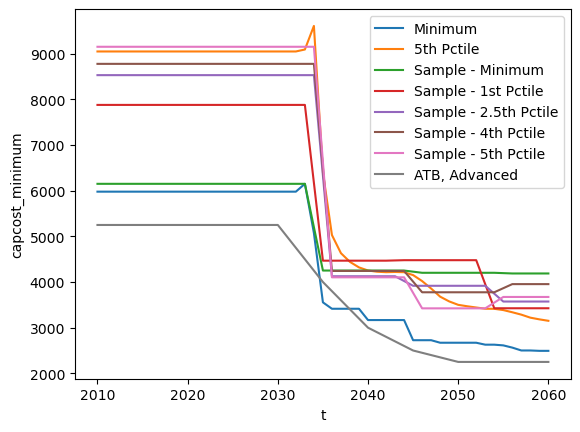

In [215]:
sb.lineplot(data = lgnuc_min_df,
            x = 't',
            y = 'capcost_minimum',
            label = 'Minimum'
           )

sb.lineplot(data = lgnuc_pi_lower,
            x = 't',
            y = 'capcost_5thpct',
            label = '5th Pctile'
           )

sb.lineplot(data = lgnuc_samples.loc[lgnuc_samples.sampl == 3684],
            x = 'years',
            y = 'capcost',
            label = 'Sample - Minimum'
           )

sb.lineplot(data = lgnuc_samples.loc[lgnuc_samples.sampl == 1573],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 1st Pctile'
           )

sb.lineplot(data = lgnuc_samples.loc[lgnuc_samples.sampl == 4792],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 2.5th Pctile'
           )

sb.lineplot(data = lgnuc_samples.loc[lgnuc_samples.sampl == 4169],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 4th Pctile'
           )

sb.lineplot(data = lgnuc_samples.loc[lgnuc_samples.sampl == 2890],
            x = 'years',
            y = 'capcost',
            label = 'Sample - 5th Pctile'
           )

sb.lineplot(data = lg_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'ATB, Advanced'
           )

<AxesSubplot: xlabel='t', ylabel='capcost_minimum'>

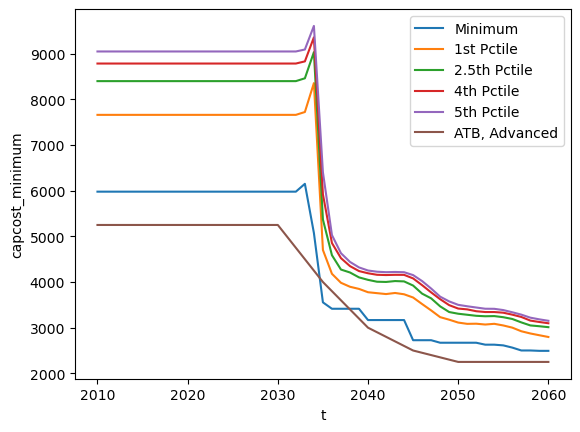

In [216]:
sb.lineplot(data = lgnuc_min_df,
            x = 't',
            y = 'capcost_minimum',
            label = 'Minimum'
           )

sb.lineplot(data = lgnuc_1_pct_df,
            x = 't',
            y = 'capcost_1stpct',
            label = '1st Pctile'
           )

sb.lineplot(data = lgnuc_2_5_pct_df,
            x = 't',
            y = 'capcost_2_5thpct',
            label = '2.5th Pctile'
           )

sb.lineplot(data = lgnuc_4_pct_df,
            x = 't',
            y = 'capcost_4thpct',
            label = '4th Pctile'
           )

sb.lineplot(data = lgnuc_pi_lower,
            x = 't',
            y = 'capcost_5thpct',
            label = '5th Pctile'
           )

sb.lineplot(data = lg_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'ATB, Advanced'
           )

<AxesSubplot: xlabel='t', ylabel='capcost'>

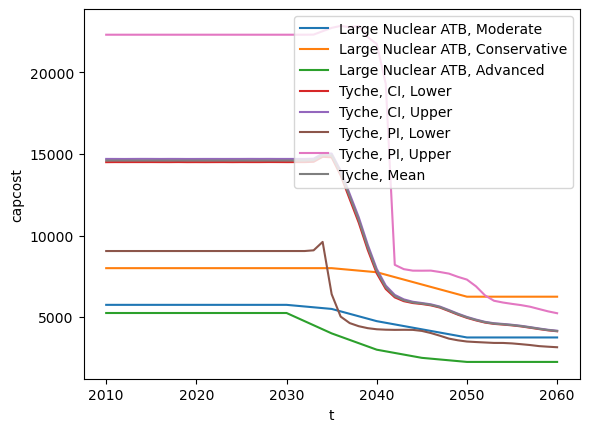

In [34]:
sb.lineplot(data = lg_atb_mod,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Moderate'
           )

sb.lineplot(data = lg_atb_con,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Conservative'
           )

sb.lineplot(data = lg_atb_adv,
            x = 't',
            y = 'capcost',
            label = 'Large Nuclear ATB, Advanced'
           )

sb.lineplot(data = lgnuc_ci_lower_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, CI, Lower'
           )

sb.lineplot(data = lgnuc_ci_upper_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, CI, Upper'
           )

sb.lineplot(data = lgnuc_pi_lower_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, PI, Lower'
           )

sb.lineplot(data = lgnuc_pi_upper_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, PI, Upper'
           )

sb.lineplot(data = lgnuc_mean_df,
            x = 't',
            y = 'capcost',
            label = 'Tyche, Mean'
           )

In [ ]:
plt.figure(figsize=(18,4))

sb.violinplot(
    data = tranches_atb_timeseries.loc[tranches_atb_timeseries.years % 5 == 1],
    x = 'years',
    y = 'capcost',
    hue = None,
)

In [ ]:
tranches_atb_timeseries.head()

In [ ]:
tranches_atb_timeseries_large = tranches_atb_timeseries.copy().loc[
    (tranches_atb_timeseries.Technology == 'Large Nuclear') &
    (tranches_atb_timeseries.years <= end_year_atb)]

In [ ]:
tranches_atb_timeseries_smr = tranches_atb_timeseries.copy().loc[
    (tranches_atb_timeseries.Technology == 'Nuclear SMR') &
    (tranches_atb_timeseries.years <= end_year_atb)]

In [ ]:
tranches_atb_timeseries_smr_median = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'median','vom':'median','capcost':'median'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_median.to_csv('nuclear-smr-tyche-50th.csv',index=False)

In [ ]:
tranches_atb_timeseries_large_median = tranches_atb_timeseries_large.groupby('years').agg({'fom':'median','vom':'median','capcost':'median'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_median.to_csv('nuclear-large-tyche-50th.csv',index=False)

In [ ]:
tranches_atb_timeseries_smr_min = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'min','vom':'min','capcost':'min'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_min.to_csv('nuclear-smr-tyche-0th.csv',index=False)

In [ ]:
tranches_atb_timeseries_large_min = tranches_atb_timeseries_large.groupby('years').agg({'fom':'min','vom':'min','capcost':'min'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_min.to_csv('nuclear-large-tyche-0th.csv',index=False)

In [ ]:
tranches_atb_timeseries_smr_max = tranches_atb_timeseries_smr.groupby('years').agg({'fom':'max','vom':'max','capcost':'max'}).reset_index()
if saveresults:
    tranches_atb_timeseries_smr_max.to_csv('nuclear-smr-tyche-100th.csv',index=False)

In [ ]:
tranches_atb_timeseries_large_max = tranches_atb_timeseries_large.groupby('years').agg({'fom':'max','vom':'max','capcost':'max'}).reset_index()
if saveresults:
    tranches_atb_timeseries_large_max.to_csv('nuclear-large-tyche-100th.csv',index=False)